In [2]:
import ee
import geemap
import geopandas as gpd

ee.Authenticate()
ee.Initialize(project='geoinformatics-spatial')

In [ ]:
# =============================================================================
# Palakkad Land Cover Classification — Google Earth Engine Pipeline
# =============================================================================
#
# Task 1: Tree / Agroforestry Cover Mapping using Sentinel-2 Time Series
#
# Classes:
#   1 = DenseForest
#   2 = Agroforestry
#   3 = SeasonalCropland
#   4 = BuiltUp
#   5 = Water
#
# Workflow:
#   1. Load manually digitized reference polygons
#   2. Create polygon-level training/validation split
#   3. Build cloud-masked Sentinel-2 composites
#   4. Calculate NDVI, EVI, NDWI and NDMI
#   5. Calculate monthly NDVI/EVI temporal variability
#   6. Build final feature stack
#   7. Sample training polygons
#   8. Train Random Forest in Earth Engine
#   9. Classify AOI
#  10. Validate using held-out polygons
#  11. Calculate accuracy and area statistics
#  12. Export classification and sample tables
#
# =============================================================================


import ee
import geemap
import geopandas as gpd
import random


# =============================================================================
# 0. INITIALIZE EARTH ENGINE
# =============================================================================

ee.Initialize()


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

# -------------------------------------------------------------------------
# Your manually digitized polygon file
# -------------------------------------------------------------------------
REFERENCE_SHP = "/content/labeled_poly_new_study_area.shp"

# -------------------------------------------------------------------------
# Class field
# -------------------------------------------------------------------------
CLASS_PROP = "class"

# -------------------------------------------------------------------------
# Validation fraction
#
# 25% of polygons from each class will be held out for validation.
# IMPORTANT:
# The split is done at POLYGON level, not pixel level.
# -------------------------------------------------------------------------
VALIDATION_FRACTION = 0.25

RANDOM_SEED = 42

# -------------------------------------------------------------------------
# Sentinel-2 date ranges
# -------------------------------------------------------------------------

POST_MONSOON = (
    "2023-10-01",
    "2023-12-31"
)

SUMMER = (
    "2024-03-01",
    "2024-05-31"
)

FULL_YEAR = (
    "2023-06-01",
    "2024-05-31"
)

# -------------------------------------------------------------------------
# Sentinel-2 spectral bands
# -------------------------------------------------------------------------

S2_BANDS = [
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B11",
    "B12"
]

# -------------------------------------------------------------------------
# Random Forest
# -------------------------------------------------------------------------

N_TREES = 500


CLASS_NAMES = {
    1: "DenseForest",
    2: "Agroforestry",
    3: "SeasonalCropland",
    4: "BuiltUp",
    5: "Water"
}


# =============================================================================
# 2. LOAD MANUALLY DIGITIZED POLYGONS
# =============================================================================

print("\nLoading reference polygons...")

reference_gdf = gpd.read_file(REFERENCE_SHP)

if reference_gdf.empty:
    raise ValueError("The reference shapefile contains no features.")

if CLASS_PROP not in reference_gdf.columns:
    raise ValueError(
        f"Class field '{CLASS_PROP}' was not found. "
        f"Available fields: {list(reference_gdf.columns)}"
    )

# Remove polygons without class labels
reference_gdf = reference_gdf.dropna(subset=[CLASS_PROP]).copy()

# Convert class field to integer
reference_gdf[CLASS_PROP] = reference_gdf[CLASS_PROP].astype(int)

# Keep only expected classes
reference_gdf = reference_gdf[
    reference_gdf[CLASS_PROP].isin(CLASS_NAMES.keys())
].copy()

if reference_gdf.empty:
    raise ValueError("No polygons with classes 1–5 were found.")


print(
    f"Loaded {len(reference_gdf)} manually digitized polygons."
)

print("\nReference polygon distribution:")

for cls, name in CLASS_NAMES.items():

    count = (reference_gdf[CLASS_PROP] == cls).sum()

    print(
        f"  {cls} = {name:<20} : {count} polygons"
    )


# =============================================================================
# 3. POLYGON-LEVEL TRAINING / VALIDATION SPLIT
# =============================================================================
#
# IMPORTANT:
# We split WHOLE POLYGONS.
#
# Pixels from one polygon must never appear in both training and validation,
# otherwise the accuracy can be artificially inflated due to spatial
# autocorrelation.
#
# =============================================================================

print("\nCreating polygon-level training/validation split...")

random.seed(RANDOM_SEED)

train_indices = []
valid_indices = []

for cls in sorted(CLASS_NAMES.keys()):

    class_indices = reference_gdf.index[
        reference_gdf[CLASS_PROP] == cls
    ].tolist()

    random.shuffle(class_indices)

    n_total = len(class_indices)

    # At least one validation polygon if possible
    if n_total >= 2:
        n_valid = max(
            1,
            int(round(n_total * VALIDATION_FRACTION))
        )
    else:
        n_valid = 0

    valid_class_indices = class_indices[:n_valid]
    train_class_indices = class_indices[n_valid:]

    # Safety: if a class only has one polygon,
    # keep it in training.
    if len(train_class_indices) == 0:
        train_class_indices = valid_class_indices
        valid_class_indices = []

    train_indices.extend(train_class_indices)
    valid_indices.extend(valid_class_indices)


train_gdf = reference_gdf.loc[train_indices].copy()
valid_gdf = reference_gdf.loc[valid_indices].copy()


print(
    f"\nTraining polygons   : {len(train_gdf)}"
)

print(
    f"Validation polygons : {len(valid_gdf)}"
)


print("\nTraining distribution:")

for cls, name in CLASS_NAMES.items():

    count = (
        train_gdf[CLASS_PROP] == cls
    ).sum()

    print(
        f"  {cls} = {name:<20} : {count}"
    )


print("\nValidation distribution:")

for cls, name in CLASS_NAMES.items():

    count = (
        valid_gdf[CLASS_PROP] == cls
    ).sum()

    print(
        f"  {cls} = {name:<20} : {count}"
    )


if len(valid_gdf) == 0:
    raise ValueError(
        "No validation polygons were created. "
        "You need at least two polygons in some/all classes."
    )


# =============================================================================
# 4. CONVERT TO EARTH ENGINE FEATURE COLLECTIONS
# =============================================================================

print("\nConverting polygons to Earth Engine...")

train_fc = geemap.geopandas_to_ee(train_gdf)

valid_fc = geemap.geopandas_to_ee(valid_gdf)


# =============================================================================
# 5. DEFINE AOI
# =============================================================================

# AOI is based on the extent of all manually digitized polygons.
#
# The 200 m buffer provides a small margin around the reference polygons.

aoi = (
    train_fc
    .merge(valid_fc)
    .geometry()
    .bounds()
    .buffer(200)
)


# =============================================================================
# 6. SENTINEL-2 CLOUD MASKING
# =============================================================================

def mask_s2_clouds(img):

    scl = img.select("SCL")

    # SCL classes retained:
    #
    # 4 = Vegetation
    # 5 = Bare soil
    # 6 = Water
    # 7 = Unclassified
    #
    # Removed:
    # 1 = Saturated/defective
    # 2 = Dark features
    # 3 = Cloud shadow
    # 8 = Cloud medium probability
    # 9 = Cloud high probability
    # 10 = Cirrus
    # 11 = Snow/ice

    good = scl.remap(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0]
    )

    return (
        img
        .updateMask(good)
        .divide(10000)
        .copyProperties(
            img,
            ["system:time_start"]
        )
    )


# =============================================================================
# 7. SENTINEL-2 COLLECTION FUNCTION
# =============================================================================

def s2_collection(start_date, end_date):

    return (
        ee.ImageCollection(
            "COPERNICUS/S2_SR_HARMONIZED"
        )
        .filterBounds(aoi)
        .filterDate(
            start_date,
            end_date
        )
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                40
            )
        )
        .map(mask_s2_clouds)
        .select(S2_BANDS)
    )


# =============================================================================
# 8. SPECTRAL INDICES
# =============================================================================

def add_indices(img):

    # NDVI
    ndvi = (
        img
        .normalizedDifference(
            ["B8", "B4"]
        )
        .rename("NDVI")
    )

    # NDWI
    ndwi = (
        img
        .normalizedDifference(
            ["B3", "B8"]
        )
        .rename("NDWI")
    )

    # NDMI
    ndmi = (
        img
        .normalizedDifference(
            ["B8", "B11"]
        )
        .rename("NDMI")
    )

    # EVI
    evi = (
        img.expression(
            "2.5 * ((NIR - RED) / "
            "(NIR + 6 * RED - 7.5 * BLUE + 1))",
            {
                "NIR": img.select("B8"),
                "RED": img.select("B4"),
                "BLUE": img.select("B2")
            }
        )
        .rename("EVI")
    )

    return img.addBands(
        [
            ndvi,
            ndwi,
            ndmi,
            evi
        ]
    )


# =============================================================================
# 9. CHECK SENTINEL-2 AVAILABILITY
# =============================================================================

print("\nChecking Sentinel-2 image availability...")

post_count = (
    s2_collection(
        *POST_MONSOON
    )
    .size()
    .getInfo()
)

summer_count = (
    s2_collection(
        *SUMMER
    )
    .size()
    .getInfo()
)

print(
    f"Post-monsoon images : {post_count}"
)

print(
    f"Summer images       : {summer_count}"
)

if post_count == 0:
    raise RuntimeError(
        "No Sentinel-2 images found for the post-monsoon period."
    )

if summer_count == 0:
    raise RuntimeError(
        "No Sentinel-2 images found for the summer period."
    )


# =============================================================================
# 10. SEASONAL COMPOSITES
# =============================================================================

print("\nCreating seasonal composites...")


post_composite = (
    s2_collection(
        *POST_MONSOON
    )
    .map(add_indices)
    .median()
)


summer_composite = (
    s2_collection(
        *SUMMER
    )
    .map(add_indices)
    .median()
)


# =============================================================================
# 11. SELECT SEASONAL FEATURES
# =============================================================================

post_bands = post_composite.select(
    [
        "B5",
        "B6",
        "B7",
        "B8A",
        "EVI",
        "NDMI",
        "NDVI",
        "NDWI"
    ],
    [
        "POST_B5",
        "POST_B6",
        "POST_B7",
        "POST_B8A",
        "POST_EVI",
        "POST_NDMI",
        "POST_NDVI",
        "POST_NDWI"
    ]
)


summer_bands = summer_composite.select(
    [
        "B5",
        "B6",
        "B7",
        "B8A",
        "EVI",
        "NDMI",
        "NDVI",
        "NDWI"
    ],
    [
        "SUMMER_B5",
        "SUMMER_B6",
        "SUMMER_B7",
        "SUMMER_B8A",
        "SUMMER_EVI",
        "SUMMER_NDMI",
        "SUMMER_NDVI",
        "SUMMER_NDWI"
    ]
)


# =============================================================================
# 12. MONTHLY PHENOLOGY / TEMPORAL VARIABILITY
# =============================================================================
#
# This section fixes the "Image.select: Band pattern 'NDVI' was applied
# to an Image with no bands" error.
#
# If a month has no Sentinel-2 imagery, a fully masked NDVI/EVI image
# is returned instead of a zero-band image.
#
# =============================================================================

print("\nBuilding monthly phenology features...")


months = ee.List.sequence(
    0,
    11
)

start = ee.Date(
    FULL_YEAR[0]
)


def monthly_indices(month_number):

    month_start = (
        start
        .advance(
            month_number,
            "month"
        )
    )

    month_end = (
        month_start
        .advance(
            1,
            "month"
        )
    )

    collection = (
        s2_collection(
            month_start,
            month_end
        )
        .map(add_indices)
    )

    # Valid fallback image containing the required bands.
    #
    # It is completely masked, so it will not contribute values
    # to temporal statistics.

    empty_image = (
        ee.Image.constant(
            [0, 0]
        )
        .rename(
            [
                "NDVI",
                "EVI"
            ]
        )
        .updateMask(
            ee.Image.constant(0)
        )
    )

    monthly_image = ee.Image(
        ee.Algorithms.If(
            collection.size().gt(0),

            collection
            .median()
            .select(
                [
                    "NDVI",
                    "EVI"
                ]
            ),

            empty_image
        )
    )

    return monthly_image


monthly_ic = (
    ee.ImageCollection
    .fromImages(
        months.map(
            monthly_indices
        )
    )
)


# =============================================================================
# 13. NDVI TEMPORAL FEATURES
# =============================================================================

ndvi_collection = (
    monthly_ic
    .select("NDVI")
)


ndvi_mean = (
    ndvi_collection
    .mean()
    .rename(
        "NDVI_MEAN"
    )
)


ndvi_range = (
    ndvi_collection
    .max()
    .subtract(
        ndvi_collection.min()
    )
    .rename(
        "NDVI_RANGE"
    )
)


ndvi_std = (
    ndvi_collection
    .reduce(
        ee.Reducer.stdDev()
    )
    .rename(
        "NDVI_STD"
    )
)


# =============================================================================
# 14. EVI TEMPORAL FEATURES
# =============================================================================

evi_collection = (
    monthly_ic
    .select("EVI")
)


evi_mean = (
    evi_collection
    .mean()
    .rename(
        "EVI_MEAN"
    )
)


evi_range = (
    evi_collection
    .max()
    .subtract(
        evi_collection.min()
    )
    .rename(
        "EVI_RANGE"
    )
)


evi_std = (
    evi_collection
    .reduce(
        ee.Reducer.stdDev()
    )
    .rename(
        "EVI_STD"
    )
)


# =============================================================================
# 15. TEMPORAL FEATURE STACK
# =============================================================================

variability_bands = ee.Image.cat(
    [
        evi_mean,
        evi_range,
        evi_std,
        ndvi_mean,
        ndvi_range,
        ndvi_std
    ]
)


# =============================================================================
# 16. FINAL FEATURE IMAGE
# =============================================================================

feature_image = (
    ee.Image.cat(
        [
            variability_bands,
            post_bands,
            summer_bands
        ]
    )
    .clip(aoi)
)


FEATURE_BANDS = feature_image.bandNames()


print("\nFinal feature bands:")

print(
    FEATURE_BANDS.getInfo()
)

print(
    "\nNumber of features:",
    FEATURE_BANDS.size().getInfo()
)


# =============================================================================
# 17. SAMPLE TRAINING POLYGONS
# =============================================================================

print("\nSampling training polygons...")


training_samples = (
    feature_image
    .sampleRegions(
        collection=train_fc,
        properties=[
            CLASS_PROP
        ],
        scale=10,
        tileScale=4,
        geometries=False
    )
)


training_count = (
    training_samples
    .size()
    .getInfo()
)


print(
    f"Training samples: {training_count:,}"
)


if training_count == 0:
    raise RuntimeError(
        "No training samples were generated. "
        "Check the polygons, AOI, CRS and Sentinel-2 coverage."
    )


# =============================================================================
# 18. TRAIN RANDOM FOREST
# =============================================================================

print("\nTraining Random Forest in Earth Engine...")


classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=N_TREES,
        minLeafPopulation=2,
        seed=RANDOM_SEED
    )
    .train(
        features=training_samples,
        classProperty=CLASS_PROP,
        inputProperties=FEATURE_BANDS
    )
)


print("Random Forest training complete.")


# =============================================================================
# 19. CLASSIFY AOI
# =============================================================================

print("\nClassifying AOI...")


classified = (
    feature_image
    .classify(
        classifier
    )
)


# =============================================================================
# 20. HELD-OUT VALIDATION
# =============================================================================

print("\nRunning held-out validation...")


validation_samples = (
    feature_image
    .sampleRegions(
        collection=valid_fc,
        properties=[
            CLASS_PROP
        ],
        scale=10,
        tileScale=4,
        geometries=False
    )
)


validation_count = (
    validation_samples
    .size()
    .getInfo()
)


print(
    f"Validation samples: {validation_count:,}"
)


if validation_count == 0:
    raise RuntimeError(
        "No validation samples were generated."
    )


validated = (
    validation_samples
    .classify(
        classifier
    )
)


# =============================================================================
# 21. ACCURACY ASSESSMENT
# =============================================================================

error_matrix = (
    validated
    .errorMatrix(
        CLASS_PROP,
        "classification"
    )
)


print("\n")
print("=" * 70)
print("ACCURACY ASSESSMENT")
print("=" * 70)


print(
    "\nConfusion Matrix:"
)

print(
    error_matrix
    .getInfo()
)


overall_accuracy = (
    error_matrix
    .accuracy()
    .getInfo()
)


kappa = (
    error_matrix
    .kappa()
    .getInfo()
)


producer_accuracy = (
    error_matrix
    .producersAccuracy()
    .getInfo()
)


consumer_accuracy = (
    error_matrix
    .consumersAccuracy()
    .getInfo()
)


print(
    f"\nOverall Accuracy : {overall_accuracy:.4f}"
)

print(
    f"Kappa            : {kappa:.4f}"
)

print(
    "\nProducer's Accuracy:"
)

print(
    producer_accuracy
)

print(
    "\nConsumer's / User's Accuracy:"
)

print(
    consumer_accuracy
)


# =============================================================================
# 22. CLASS AREA STATISTICS
# =============================================================================
#
# Required for the Task 1 output / report.
#
# Area is calculated from the classified map in km².
#
# =============================================================================

print("\nCalculating classified area...")


area_image = (
    ee.Image.pixelArea()
    .divide(1e6)
    .addBands(
        classified
    )
)


area_by_class = (
    area_image
    .reduceRegion(
        reducer=ee.Reducer.sum()
        .group(
            groupField=1,
            groupName="class"
        ),
        geometry=aoi,
        scale=10,
        maxPixels=1e9,
        tileScale=4
    )
)


area_results = (
    area_by_class
    .getInfo()
)


print("\n")
print("=" * 70)
print("CLASSIFIED AREA")
print("=" * 70)


if area_results and "groups" in area_results:

    for group in area_results["groups"]:

        class_id = int(
            group["class"]
        )

        area_km2 = group["sum"]

        class_name = CLASS_NAMES.get(
            class_id,
            f"Class {class_id}"
        )

        print(
            f"{class_id} - "
            f"{class_name:<20} "
            f"{area_km2:.2f} km²"
        )

else:

    print(
        "No area statistics were returned."
    )


# =============================================================================
# 23. EXPORT CLASSIFIED MAP
# =============================================================================

print("\nStarting classified map export...")


ee.batch.Export.image.toDrive(
    image=classified.toByte(),
    description="Palakkad_LandCover_RF",
    folder="EarthEngine_Exports",
    fileNamePrefix="palakkad_landcover_rf",
    region=aoi,
    scale=10,
    maxPixels=1e9
).start()


# =============================================================================
# 24. EXPORT TRAINING SAMPLES
# =============================================================================

print(
    "Starting training sample export..."
)


ee.batch.Export.table.toDrive(
    collection=training_samples,
    description="Palakkad_Training_Samples_Export",
    folder="EarthEngine_Exports",
    fileNamePrefix="Palakkad_RF_Training_Samples",
    fileFormat="CSV"
).start()


# =============================================================================
# 25. EXPORT VALIDATION SAMPLES
# =============================================================================

print(
    "Starting validation sample export..."
)


ee.batch.Export.table.toDrive(
    collection=validation_samples,
    description="Palakkad_Validation_Samples_Export",
    folder="EarthEngine_Exports",
    fileNamePrefix="Palakkad_RF_Validation_Samples",
    fileFormat="CSV"
).start()


# =============================================================================
# 26. FINAL SUMMARY
# =============================================================================

print("\n")
print("=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)

print(
    f"\nNumber of features : "
    f"{FEATURE_BANDS.size().getInfo()}"
)

print(
    f"Training polygons  : "
    f"{len(train_gdf)}"
)

print(
    f"Validation polygons: "
    f"{len(valid_gdf)}"
)

print(
    f"Training samples   : "
    f"{training_count:,}"
)

print(
    f"Validation samples : "
    f"{validation_count:,}"
)

print(
    f"Overall accuracy   : "
    f"{overall_accuracy:.4f}"
)

print(
    f"Kappa              : "
    f"{kappa:.4f}"
)

print(
    "\nExports have been started."
)

print(
    "Open the Earth Engine Tasks tab "
    "to monitor the exports."
)

print(
    "\nGoogle Drive folder:"
)

print(
    "EarthEngine_Exports/"
)

Loaded 62,890 pixel samples from 346 polygons
class
SeasonalCropland    47108
Agroforestry         6997
BuiltUp              4782
DenseForest          2181
Water                1822
Name: count, dtype: int64 

Train: 47,537 px from 259 polygons
Test : 15,353 px from 87 polygons (held out)

Overall Accuracy : 0.9480
Kappa coefficient: 0.8751
                  precision    recall  f1-score   support

     DenseForest      0.980     0.822     0.894       706
    Agroforestry      0.813     0.842     0.827      1807
SeasonalCropland      0.972     0.974     0.973     11486
         BuiltUp      0.933     0.956     0.944      1198
           Water      0.795     0.769     0.782       156

        accuracy                          0.948     15353
       macro avg      0.898     0.873     0.884     15353
    weighted avg      0.949     0.948     0.948     15353


Confusion matrix with Producer's Accuracy (recall):
                       Pred_DenseForest  Pred_Agroforestry  \
True_DenseForest 

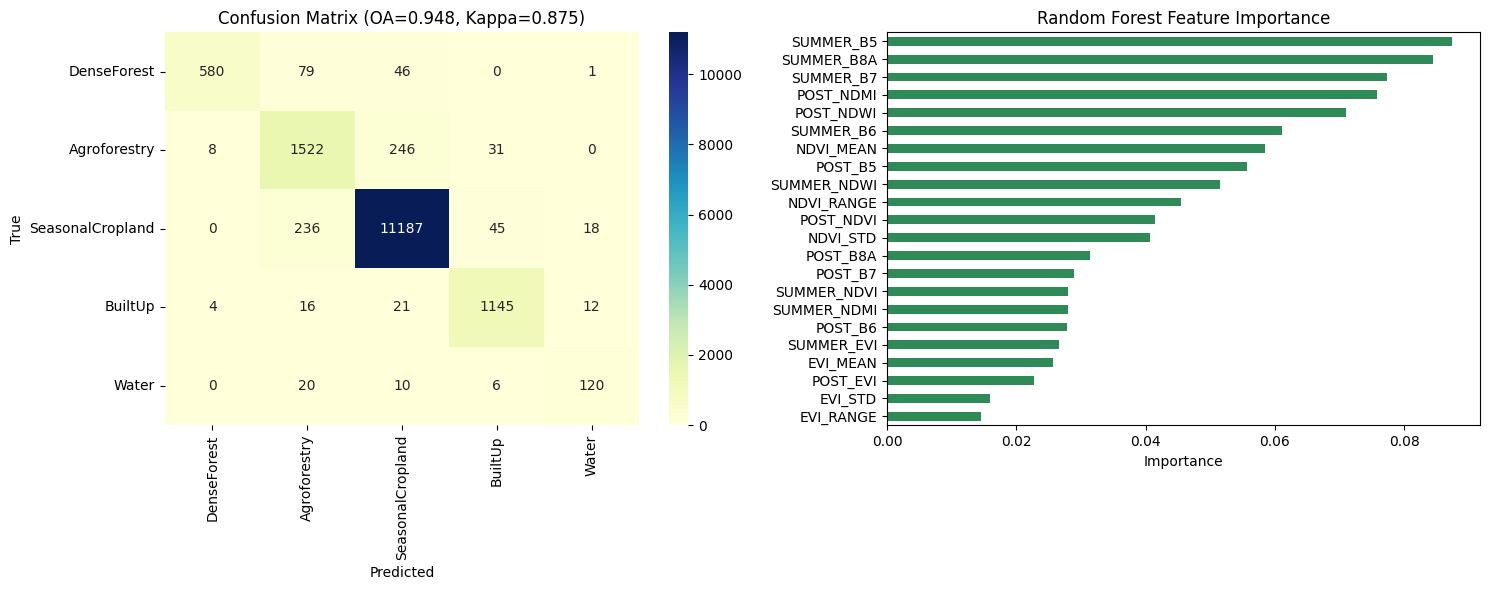

In [5]:
"""
Palakkad Land Cover Classification — Random Forest Training & Accuracy Assessment
===================================================================================
Input : Palakkad_RF_Training_Samples.csv
        (pixel samples with Sentinel-2 seasonal composite bands/indices,
         exported from Earth Engine using 01_gee_pipeline.py)

Classes: 1 = DenseForest, 2 = Agroforestry, 3 = SeasonalCropland,
         4 = BuiltUp,     5 = Water

IMPORTANT — why a plain random train/test split is wrong here
---------------------------------------------------------------
Each row in the CSV is a *pixel* sampled from inside a hand-digitised
*polygon* (visible from the `system:index` field, e.g. "..._3_0", "..._3_1"
are two pixels from the same polygon "..._3"). Pixels from the same polygon
are spatially autocorrelated (same field, same tree crown, same rooftop),
so a random pixel-level split leaks near-duplicate information between
train and test and will overestimate accuracy. This script splits by
POLYGON, stratified by class, so entire polygons — not individual pixels —
go either to training or to the held-out validation set.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
)

# --------------------------------------------------------------------------
# 0. Config
# --------------------------------------------------------------------------
CSV_PATH = "/content/Palakkad_RF_Training_Samples.csv"
TEST_FRACTION = 0.25          # fraction of POLYGONS per class held out for validation
RANDOM_STATE = 42
N_TREES = 500

CLASS_NAMES = {
    1: "DenseForest",
    2: "Agroforestry",
    3: "SeasonalCropland",
    4: "BuiltUp",
    5: "Water",
}

FEATURE_COLS = [
    "EVI_MEAN", "EVI_RANGE", "EVI_STD",
    "NDVI_MEAN", "NDVI_RANGE", "NDVI_STD",
    "POST_B5", "POST_B6", "POST_B7", "POST_B8A",
    "POST_EVI", "POST_NDMI", "POST_NDVI", "POST_NDWI",
    "SUMMER_B5", "SUMMER_B6", "SUMMER_B7", "SUMMER_B8A",
    "SUMMER_EVI", "SUMMER_NDMI", "SUMMER_NDVI", "SUMMER_NDWI",
]

# --------------------------------------------------------------------------
# 1. Load data
# --------------------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

# Recover the source polygon id from the GEE system:index
# (format: "<polygon_index>_<pixel_index>")
df["poly_id"] = df["system:index"].str.rsplit("_", n=1).str[0]

print(f"Loaded {len(df):,} pixel samples from {df['poly_id'].nunique()} polygons")
print(df["class"].map(CLASS_NAMES).value_counts(), "\n")

# --------------------------------------------------------------------------
# 2. Polygon-level, class-stratified train/validation split
# --------------------------------------------------------------------------
rng = np.random.RandomState(RANDOM_STATE)
poly_class = df.groupby("poly_id")["class"].first()

test_polys = []
for cls, group in poly_class.groupby(poly_class):
    ids = group.index.to_numpy()
    rng.shuffle(ids)
    n_test = max(1, int(round(len(ids) * TEST_FRACTION)))  # >=1 polygon/class in test
    test_polys.extend(ids[:n_test])
test_polys = set(test_polys)

is_test = df["poly_id"].isin(test_polys)

X_train = df.loc[~is_test, FEATURE_COLS].values
X_test = df.loc[is_test, FEATURE_COLS].values
y_train = df.loc[~is_test, "class"].values
y_test = df.loc[is_test, "class"].values

print(f"Train: {len(y_train):,} px from {poly_class.shape[0]-len(test_polys)} polygons")
print(f"Test : {len(y_test):,} px from {len(test_polys)} polygons (held out)\n")

# --------------------------------------------------------------------------
# 3. Train Random Forest
#    class_weight='balanced' compensates for the heavy skew toward
#    SeasonalCropland (~75% of samples) vs. DenseForest/Water (~3% each).
# --------------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=N_TREES,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

# --------------------------------------------------------------------------
# 4. Accuracy assessment
# --------------------------------------------------------------------------
labels_sorted = sorted(CLASS_NAMES.keys())
names_sorted = [CLASS_NAMES[c] for c in labels_sorted]

acc = accuracy_score(y_test, pred)
kappa = cohen_kappa_score(y_test, pred)
cm = confusion_matrix(y_test, pred, labels=labels_sorted)

print("=" * 60)
print(f"Overall Accuracy : {acc:.4f}")
print(f"Kappa coefficient: {kappa:.4f}")
print("=" * 60)
print(classification_report(y_test, pred, labels=labels_sorted,
                             target_names=names_sorted, digits=3))

# Producer's / user's accuracy table (row = truth, col = predicted)
cm_df = pd.DataFrame(cm, index=[f"True_{n}" for n in names_sorted],
                      columns=[f"Pred_{n}" for n in names_sorted])
producers_acc = np.diag(cm) / cm.sum(axis=1)   # recall per class
users_acc = np.diag(cm) / cm.sum(axis=0)       # precision per class
cm_df["Producer_Acc"] = np.round(producers_acc, 3)
print("\nConfusion matrix with Producer's Accuracy (recall):")
print(cm_df)
print("\nUser's Accuracy (precision) per class:")
print(pd.Series(np.round(users_acc, 3), index=names_sorted))

# --------------------------------------------------------------------------
# 5. Plots: confusion matrix heatmap + feature importance
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=names_sorted, yticklabels=names_sorted, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title(f"Confusion Matrix (OA={acc:.3f}, Kappa={kappa:.3f})")

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("rf_accuracy_report.png", dpi=150)
print("\nSaved figure: rf_accuracy_report.png")

# --------------------------------------------------------------------------
# 6. Notes on confused classes (auto-generated from the confusion matrix)
# --------------------------------------------------------------------------
print("\nMost confused class pairs:")
off_diag = cm.copy().astype(float)
np.fill_diagonal(off_diag, 0)
flat_idx = np.dstack(np.unravel_index(np.argsort(-off_diag.ravel()), off_diag.shape))[0]
for i, j in flat_idx[:5]:
    if off_diag[i, j] > 0:
        print(f"  True {names_sorted[i]:<17s} -> Predicted {names_sorted[j]:<17s} : "
              f"{int(off_diag[i, j])} px")

print("""
Interpretation:
- Agroforestry <-> SeasonalCropland is typically the largest confusion:
  both are actively vegetated, both show strong NDVI/EVI in the post-monsoon
  season, and field-boundary / mixed pixels fall spectrally between the two
  classes. Denser, more permanent tree cover (home-gardens, coconut/areca
  plantations) overlaps agroforestry's spectral-temporal signature.
- DenseForest <-> Agroforestry confusion arises because both are
  tree-dominated; the SUMMER-season indices (deciduous/semi-deciduous
  canopy thinning in cropland/agroforestry vs. evergreen forest) are the
  main separating signal — this is why SUMMER_* bands rank high in
  feature importance.
- Water and BuiltUp are best separated (highest producer's/user's accuracy)
  since their spectral response is comparatively distinct in both seasons.
- DenseForest has only ~6 training polygons in this dataset, which limits
  how well the classifier can learn its full within-class variability;
  more forest reference polygons (or use of ESA WorldCover as auxiliary
  reference) would likely raise its accuracy further.
""")

# --------------------------------------------------------------------------
# 7. Persist the trained model for reuse (e.g., to score new pixels
#    exported the same way from Earth Engine)
# --------------------------------------------------------------------------
import joblib
joblib.dump({"model": rf, "feature_cols": FEATURE_COLS, "class_names": CLASS_NAMES},
            "rf_palakkad_model.joblib")
print("Saved trained model: rf_palakkad_model.joblib")


In [16]:
"""
Palakkad Land Cover Classification — Earth Engine Data Pipeline
===================================================================
Builds the exact feature stack used in Palakkad_RF_Training_Samples.csv,
trains a Random Forest classifier IN Earth Engine, classifies the full
AOI, and runs an accuracy assessment against an INDEPENDENT validation
polygon set (labeled_poly_new_study_area.shp) — i.e. validation polygons
that were never used for training, per the assignment's "held-out
validation sample" requirement.

Run this in an environment with Earth Engine authenticated, e.g.:
    pip install earthengine-api geemap geopandas
    earthengine authenticate      # once, interactively
    python 01_gee_pipeline.py

Classes: 1=DenseForest 2=Agroforestry 3=SeasonalCropland 4=BuiltUp 5=Water
"""

import ee
import geemap
import geopandas as gpd

# --------------------------------------------------------------------------
# 0. Config
# --------------------------------------------------------------------------
TRAIN_SHP = "/content/training_palakkad_cleaned.shp"          # used to TRAIN the model
VALID_SHP = "/content/labeled_poly_new_study_area.shp"         # INDEPENDENT accuracy check
CLASS_PROP = "class"


# Seasons for Kerala (adjust to the actual imaging year(s) you need)
POST_MONSOON = ("2023-10-01", "2023-12-31")   # post-monsoon composite
SUMMER = ("2024-03-01", "2024-05-31")         # dry-season composite
FULL_YEAR = ("2023-06-01", "2024-05-31")      # for monthly phenology metrics

S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

N_TREES = 500

# --------------------------------------------------------------------------
# 1. AOI + reference polygons -> Earth Engine FeatureCollections
# --------------------------------------------------------------------------
train_gdf = gpd.read_file(TRAIN_SHP)
valid_gdf = gpd.read_file(VALID_SHP)


def _resolve_class_column(gdf, path):
    """Find the class-label column even if its name/case differs from
    'class' (e.g. DBF field truncation, alternate naming like 'Class',
    'CLASS_ID', 'class_name' as a fallback last resort)."""
    if CLASS_PROP in gdf.columns:
        return CLASS_PROP
    lower_map = {c.lower(): c for c in gdf.columns}
    if CLASS_PROP in lower_map:
        return lower_map[CLASS_PROP]
    candidates = [c for c in gdf.columns if "class" in c.lower()]
    print(f"WARNING: column '{CLASS_PROP}' not found in {path}.")
    print(f"  Available columns: {list(gdf.columns)}")
    if candidates:
        chosen = candidates[0]
        print(f"  Using closest match: '{chosen}'")
        return chosen
    raise KeyError(
        f"No class-label column found in {path}. "
        f"Available columns are: {list(gdf.columns)}. "
        f"Update CLASS_PROP or the matching logic above to point at the right field."
    )


train_class_col = _resolve_class_column(train_gdf, TRAIN_SHP)
valid_class_col = _resolve_class_column(valid_gdf, VALID_SHP)

# Normalize both to a single canonical column name ('class') with a plain
# int dtype, so everything downstream can keep using CLASS_PROP regardless
# of what the source field was actually called.
train_gdf[CLASS_PROP] = train_gdf[train_class_col].astype(int)
valid_gdf[CLASS_PROP] = valid_gdf[valid_class_col].astype(int)

train_fc = geemap.geopandas_to_ee(train_gdf)
valid_fc = geemap.geopandas_to_ee(valid_gdf)

# AOI = bounding box of both reference layers, buffered slightly
aoi = train_fc.merge(valid_fc).geometry().bounds().buffer(200)

# --------------------------------------------------------------------------
# 2. Cloud masking (Sentinel-2 SR Harmonized, using the QA60 / SCL band)
# --------------------------------------------------------------------------
def mask_s2_clouds(img):
    scl = img.select("SCL")
    # keep vegetation, bare soil, water, unclassified; drop cloud/shadow/cirrus/snow
    good = scl.remap(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
    )
    return img.updateMask(good).divide(10000).copyProperties(img, ["system:time_start"])


def s2_collection(start, end):
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
        .map(mask_s2_clouds)
        .select(S2_BANDS)
    )


# Placeholder (fully masked) image with the S2 band names, used whenever a
# date window has zero images (e.g. a gappy month) so .median()/.select()
# never crashes on a bandless image.
_S2_PLACEHOLDER = ee.Image.constant([0] * len(S2_BANDS)).rename(S2_BANDS).updateMask(0)


def safe_s2_median(start, end):
    """Median composite for a date range; falls back to an all-masked
    placeholder image (with the same band names) if no images exist."""
    coll = s2_collection(start, end)
    composite = ee.Image(
        ee.Algorithms.If(coll.size().gt(0), coll.median(), _S2_PLACEHOLDER)
    )
    return ee.Image(composite)


# --------------------------------------------------------------------------
# 3. Spectral indices
# --------------------------------------------------------------------------
def add_indices(img):
    ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = img.normalizedDifference(["B3", "B8"]).rename("NDWI")
    ndmi = img.normalizedDifference(["B8", "B11"]).rename("NDMI")
    evi = img.expression(
        "2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))",
        {"NIR": img.select("B8"), "RED": img.select("B4"), "BLUE": img.select("B2")},
    ).rename("EVI")
    return img.addBands([ndvi, ndwi, ndmi, evi])


# --------------------------------------------------------------------------
# 4. Seasonal median composites (post-monsoon, summer)
# --------------------------------------------------------------------------
post_composite = add_indices(safe_s2_median(*POST_MONSOON))
summer_composite = add_indices(safe_s2_median(*SUMMER))

post_bands = post_composite.select(
    ["B5", "B6", "B7", "B8A", "EVI", "NDMI", "NDVI", "NDWI"],
    ["POST_B5", "POST_B6", "POST_B7", "POST_B8A", "POST_EVI", "POST_NDMI", "POST_NDVI", "POST_NDWI"],
)
summer_bands = summer_composite.select(
    ["B5", "B6", "B7", "B8A", "EVI", "NDMI", "NDVI", "NDWI"],
    ["SUMMER_B5", "SUMMER_B6", "SUMMER_B7", "SUMMER_B8A", "SUMMER_EVI",
     "SUMMER_NDMI", "SUMMER_NDVI", "SUMMER_NDWI"],
)

# --------------------------------------------------------------------------
# 5. Seasonal-variability ("texture-in-time") metrics
#    NDVI/EVI mean/range/std computed directly across every individual
#    cloud-masked Sentinel-2 scene in the full year (not pre-binned into
#    monthly composites), which captures phenological differences between
#    evergreen forest, agroforestry, and seasonal cropland and stands in
#    for a spatial texture metric. Computing straight off the per-scene
#    collection also avoids Earth Engine's ImageCollection band-type
#    homogeneity requirement that a monthly placeholder/composite
#    approach can trip over when some months have zero clear scenes.
# --------------------------------------------------------------------------
s2_full_year = s2_collection(*FULL_YEAR).map(add_indices).select(["NDVI", "EVI"])

ndvi_ic = s2_full_year.select("NDVI")
evi_ic = s2_full_year.select("EVI")

ndvi_mean = ndvi_ic.mean().rename("NDVI_MEAN")
ndvi_range = ndvi_ic.max().subtract(ndvi_ic.min()).rename("NDVI_RANGE")
ndvi_std = ndvi_ic.reduce(ee.Reducer.stdDev()).rename("NDVI_STD")

evi_mean = evi_ic.mean().rename("EVI_MEAN")
evi_range = evi_ic.max().subtract(evi_ic.min()).rename("EVI_RANGE")
evi_std = evi_ic.reduce(ee.Reducer.stdDev()).rename("EVI_STD")

variability_bands = ee.Image.cat(
    [evi_mean, evi_range, evi_std, ndvi_mean, ndvi_range, ndvi_std]
)

# --------------------------------------------------------------------------
# 6. Final stacked feature image
# --------------------------------------------------------------------------
feature_image = ee.Image.cat([variability_bands, post_bands, summer_bands]).clip(aoi)
FEATURE_BANDS = feature_image.bandNames()

# --------------------------------------------------------------------------
# 7. Sample TRAINING polygons -> labelled FeatureCollection
# --------------------------------------------------------------------------
training_samples = feature_image.sampleRegions(
    collection=train_fc,
    properties=[CLASS_PROP],
    scale=10,
    tileScale=4,
    geometries=False,
)

# --------------------------------------------------------------------------
# 8. Train Random Forest classifier
# --------------------------------------------------------------------------
classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=N_TREES, minLeafPopulation=2, seed=42
).train(
    features=training_samples,
    classProperty=CLASS_PROP,
    inputProperties=FEATURE_BANDS,
)

# --------------------------------------------------------------------------
# 9. Classify the full AOI
# --------------------------------------------------------------------------
classified = feature_image.classify(classifier)

# --------------------------------------------------------------------------
# 10. INDEPENDENT accuracy assessment using labeled_poly_new_study_area
#     (polygons never used to train the model)
# --------------------------------------------------------------------------
validation_samples = feature_image.sampleRegions(
    collection=valid_fc,
    properties=[CLASS_PROP],
    scale=10,
    tileScale=4,
    geometries=False,
)
validated = validation_samples.classify(classifier)

error_matrix = validated.errorMatrix(CLASS_PROP, "classification")
print("Confusion matrix:", error_matrix.getInfo())
print("Overall accuracy:", error_matrix.accuracy().getInfo())
print("Kappa:", error_matrix.kappa().getInfo())
print("Producer's accuracy (per class):", error_matrix.producersAccuracy().getInfo())
print("Consumer's/User's accuracy (per class):", error_matrix.consumersAccuracy().getInfo())

# --------------------------------------------------------------------------
# 11. Exports
# --------------------------------------------------------------------------
# 11a. Classified land-cover map -> Google Drive
ee.batch.Export.image.toDrive(
    image=classified.toByte(),
    description="Palakkad_LandCover_RF",
    folder="EarthEngine_Exports",
    fileNamePrefix="palakkad_landcover_rf",
    region=aoi,
    scale=10,
    maxPixels=1e9,
).start()

# 11b. Training + validation sample tables (feature bands + class) -> Drive,
#      for reproducibility / re-training locally with scikit-learn
ee.batch.Export.table.toDrive(
    collection=training_samples,
    description="Palakkad_Training_Samples_Export",
    folder="EarthEngine_Exports",
    fileFormat="CSV",
).start()

ee.batch.Export.table.toDrive(
    collection=validation_samples,
    description="Palakkad_Validation_Samples_Export",
    folder="EarthEngine_Exports",
    fileFormat="CSV",
).start()

print("\nExports started. Check the Earth Engine 'Tasks' tab (or GEE Code Editor) "
      "for progress; outputs will appear in Google Drive under EarthEngine_Exports/.")

Confusion matrix: [[0, 0, 0, 0, 0, 0], [0, 3132, 1, 0, 0, 0], [0, 4, 10203, 143, 4, 1], [0, 1, 189, 65928, 1, 2], [0, 8, 37, 48, 6801, 0], [0, 1, 12, 5, 6, 614]]
Overall accuracy: 0.994686772013174
Kappa: 0.987282117969699
Producer's accuracy (per class): [[0], [0.999680817108203], [0.9853211009174312], [0.9970811088761513], [0.9865100087032201], [0.9623824451410659]]
Consumer's/User's accuracy (per class): [[0, 0.9961844197138314, 0.9778714436248683, 0.9971266975168618, 0.9983854396007632, 0.9967637540453075]]

Exports started. Check the Earth Engine 'Tasks' tab (or GEE Code Editor) for progress; outputs will appear in Google Drive under EarthEngine_Exports/.
